<a href="https://colab.research.google.com/github/masterinfo/COURS_ELEARNING/blob/master/vectorisation_mongodb_atlas_wilfrid_Morell_chat_rag_reranking_version_finale_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

La vectorisation, c’est la transformation d’un objet (texte, image, film, etc.) en un vecteur numérique (une liste de nombres) dans un espace à plusieurs dimensions (par exemple 1536 dimensions).
Vectorisation pour kNN et k-means

    k-Nearest Neighbors (kNN) :
    C’est une méthode qui, pour un vecteur donné (représentant une requête), cherche les k vecteurs les plus proches dans l’espace vectoriel.
    La “distance” ou “proximité” se mesure souvent avec des métriques comme la similarité cosinus, la distance Euclidienne (L2), ou le produit scalaire (dot product).
    La vectorisation est donc utile pour représenter les objets dans cet espace, permettant ensuite de calculer ces distances.

    k-Means clustering :
    C’est une méthode non supervisée qui groupe les vecteurs similaires en k clusters, en minimisant la distance à un vecteur central appelé centroïde.
    Ici aussi, il faut des données vectorielles pour que l’algorithme fonctionne.

Pourquoi utiliser la vectorisation pour ces méthodes ?

    Les objets complexes comme des textes ou films ne sont pas directement exploitables numériquement.

    La vectorisation permet de coder ces objets dans un espace numérique à dimension fixe, facilitant le calcul de similarité.

    Par exemple, un film devient un vecteur 1536D décrit par ses caractéristiques sémantiques.


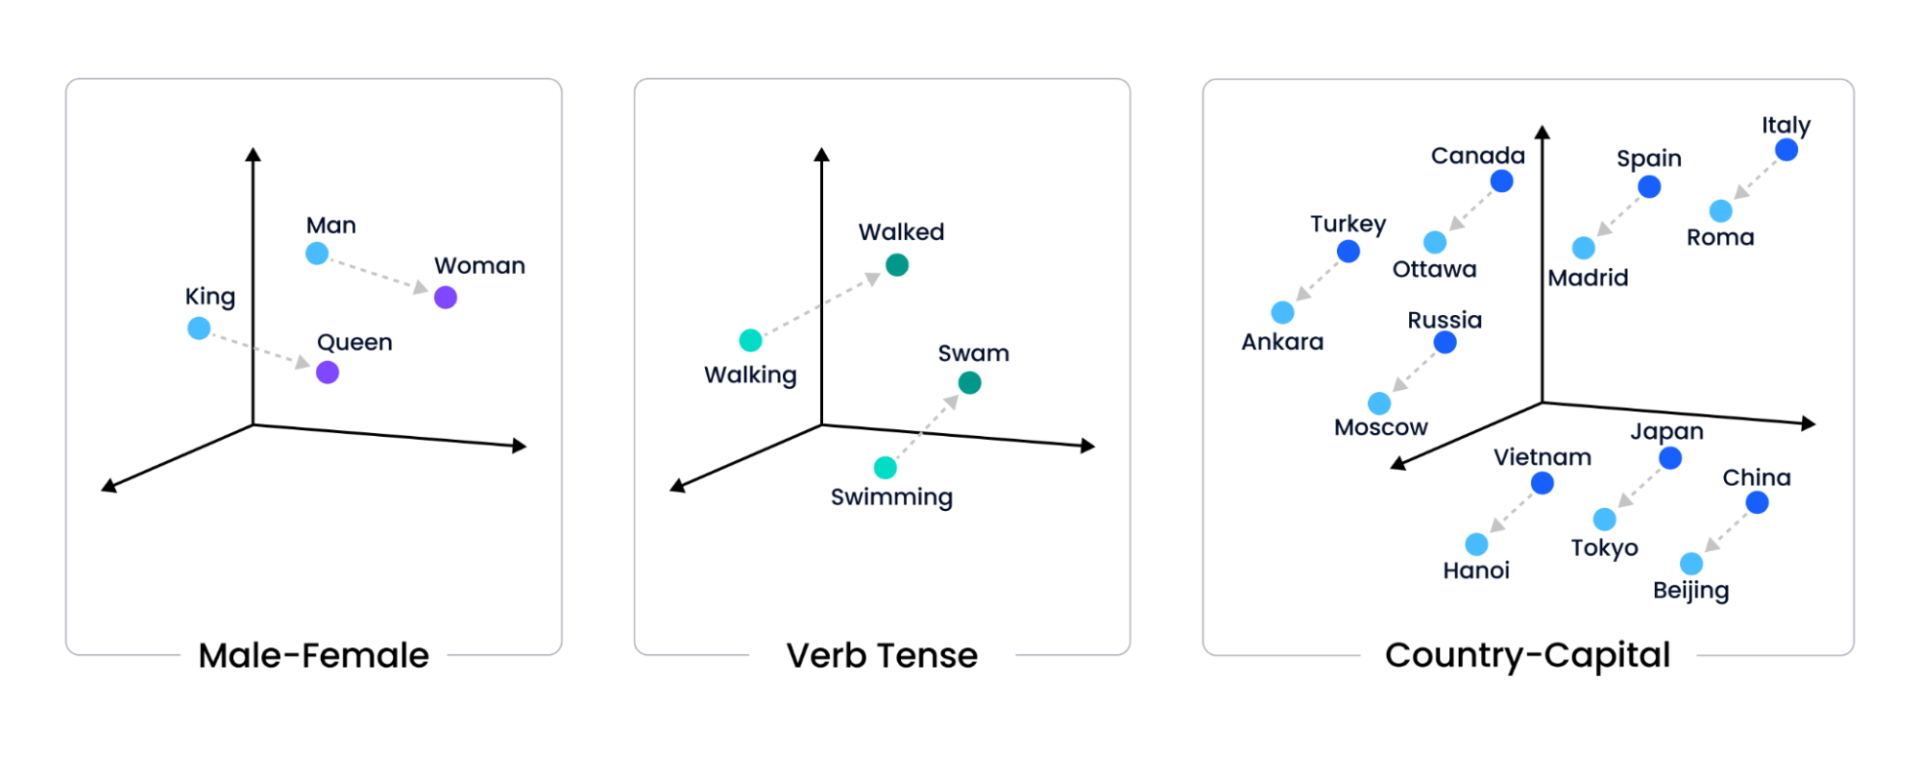

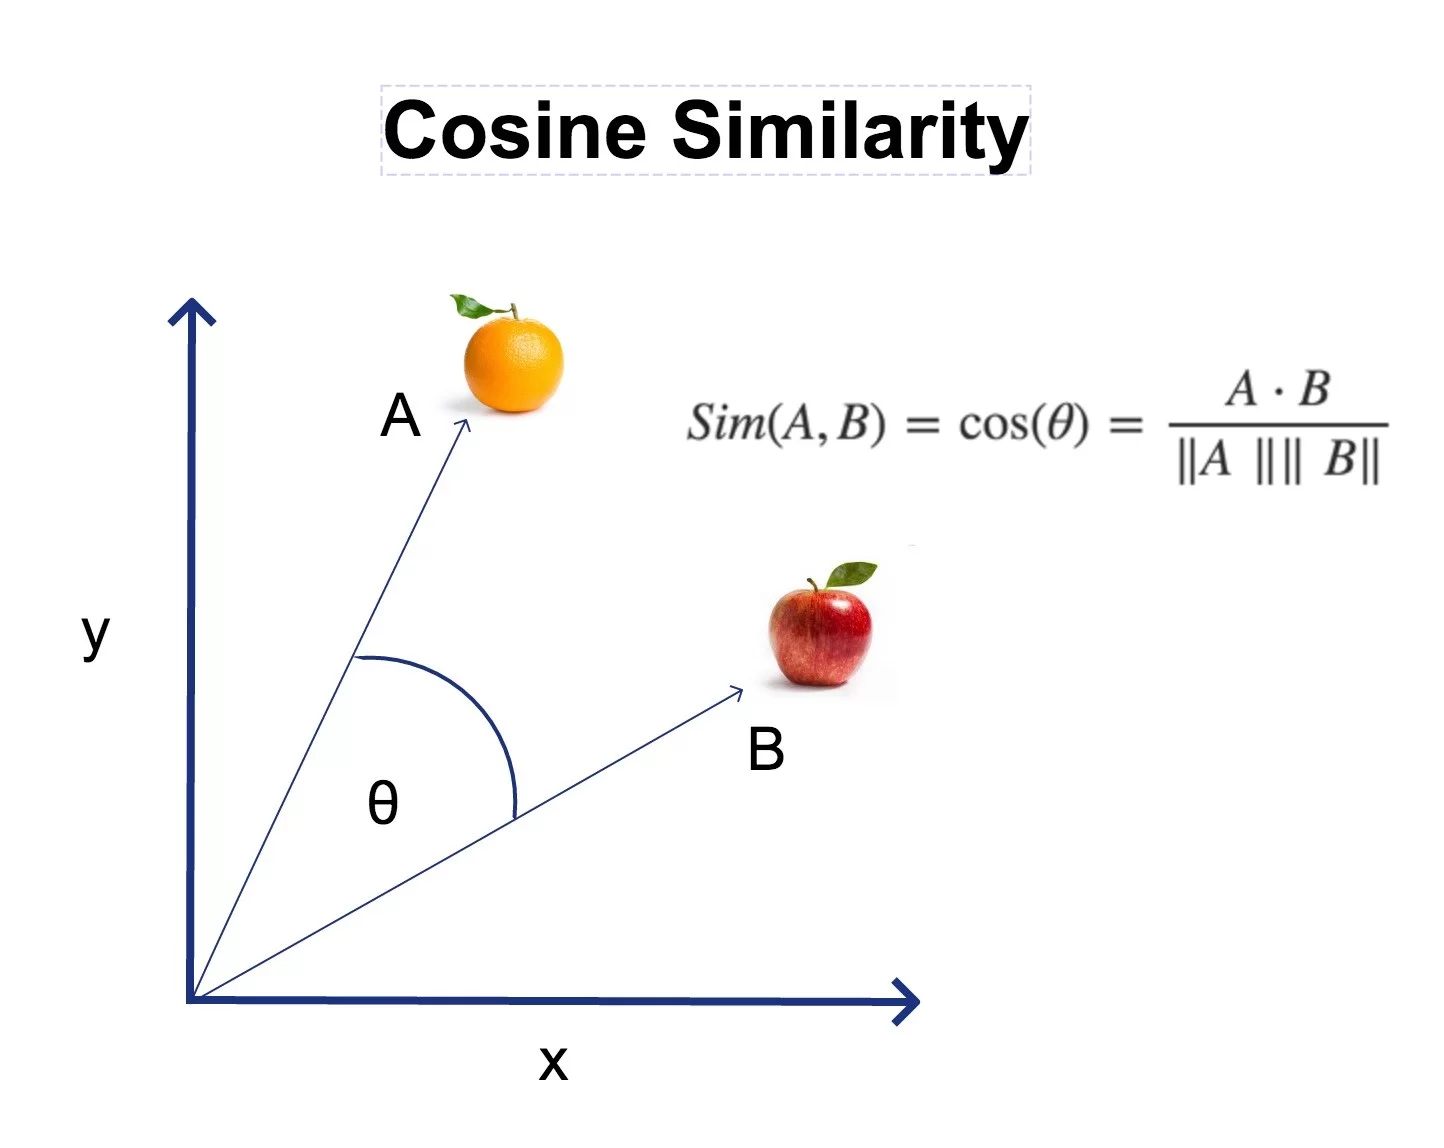

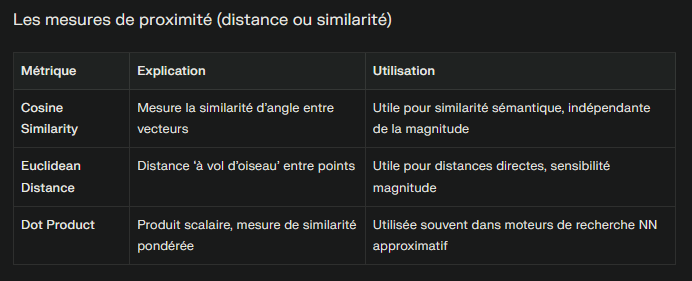

MongoDB Atlas supporte la vector search pour des vecteurs d’une taille allant jusqu’à 8192

Les films ont été enregistrer a parti du fichier python en local

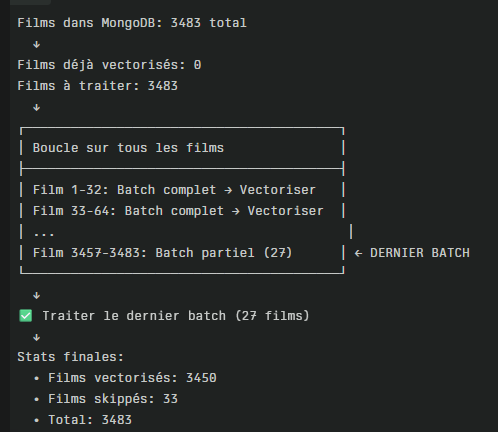

In [ ]:
! pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 45.0 MB/s eta 0:00:00


In [ ]:
!pip install sentence-transformers tqdm torch

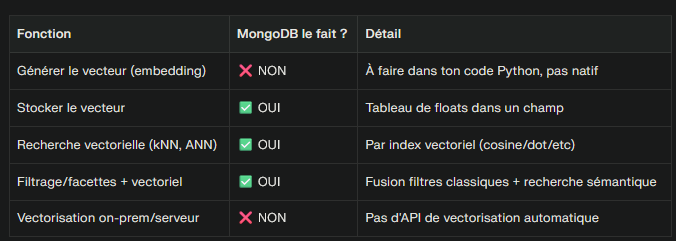

In [ ]:

from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi

from google.colab import userdata
uri = userdata.get("MONGODB_URI")

# Create a new client and connect to the server
client = MongoClient(uri, server_api=ServerApi('1'))

# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

Pinged your deployment. You successfully connected to MongoDB!


In [ ]:
import torch

# Détection GPU/CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"💻 Device détecté: {device.upper()}")

💻 Device détecté: CUDA


In [ ]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import time


In [ ]:

# ✅ Charger le modèle gte-Qwen2 (meilleur pour films)
print("\n📦 Chargement du modèle gte-Qwen2-1.5B-instruct...")
model = SentenceTransformer('Alibaba-NLP/gte-Qwen2-1.5B-instruct').to(device)
print(f"✅ Modèle chargé sur {device}")
print(f"📏 Dimension des embeddings: {model.get_sentence_embedding_dimension()}")



📦 Chargement du modèle gte-Qwen2-1.5B-instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/284 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

✅ Modèle chargé sur cuda
📏 Dimension des embeddings: 1536


In [ ]:
# Connexion à la collection
db = client["sample_mflix"]
collection = db["embedded_movies"]

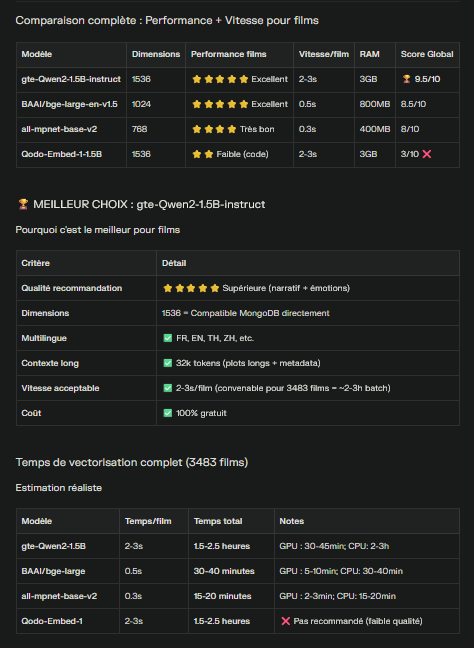

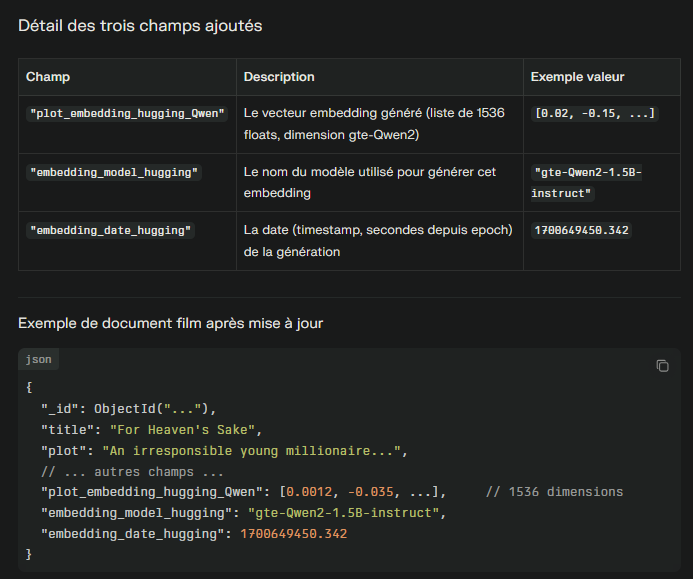

**Creation d'un champs d'embedding vectorisé de 1536 dimensions**

In [ ]:
def build_text_for_embedding(movie):
    parts = []

    if movie.get("title"):
        parts.append(f"Title: {movie['title']}")

    if movie.get("genres"):
        parts.append(f"Genres: {', '.join(movie['genres'])}")

    if movie.get("directors"):
        parts.append(f"Directors: {', '.join(movie['directors'])}")

    if movie.get("cast"):
        parts.append(f"Cast: {', '.join(movie['cast'][:5])}")  # top 5

    if movie.get("awards", {}).get("text"):
        parts.append(f"Awards: {movie['awards']['text']}")

    if movie.get("plot"):           # si présent quand même
        parts.append(f"Plot: {movie['plot']}")

    if movie.get("fullplot"):       # idem
        parts.append(f"Full plot: {movie['fullplot']}")

    return " | ".join(parts)

In [ ]:
# Compter les films à traiter (ceux qui n'ont pas encore le nouveau champ ou vide)
query_filter = {
    # "$or": [
    #     {"plot_embedding_hugging_Qwen": {"$exists": False}},
    #     {"plot_embedding_hugging_Qwen": []}
    # ]
}
total = collection.count_documents(query_filter)
print(f"\n📊 Films à traiter: {total}")


📊 Films à traiter: 3483


In [ ]:
remplace=1
if remplace == 0:
    print("✅ Tous les films ont déjà été vectorisés!")
else:
    # Timer
    start_time = time.time()
    films_traites = 0

    # Traitement par batch pour efficacité
    batch_size = 32
    batch_texts = []
    batch_ids = []

    cursor = collection.find(query_filter).batch_size(batch_size)

    print(f"\n🚀 Début de la vectorisation (batch_size={batch_size})...")

    for film in tqdm(cursor, total=total, desc="Vectorisation", unit="film"):
        try:


            # Ajouter au batch

            # appel a la fonction pour la vectorisation
            text_to_vectorize =  build_text_for_embedding(film)
            batch_texts.append(text_to_vectorize)
            batch_ids.append(film['_id'])

            # Traiter le batch quand il est plein
            if len(batch_texts) == batch_size:
                # Encoder tout le batch (plus efficace que un par un)
                embeddings = model.encode(
                    batch_texts,
                    batch_size=batch_size,
                    show_progress_bar=False,
                    convert_to_tensor=False,
                    normalize_embeddings=True,
                    device=device
                )

                # Mettre à jour MongoDB avec le nouveau champ
                for film_id, embedding in zip(batch_ids, embeddings):
                    collection.update_one(
                        {"_id": film_id},
                        {
                            "$set": {
                                "plot_embedding_hugging_Qwen": embedding.tolist(),  # ✅ Nouveau champ
                                "embedding_model_hugging": "gte-Qwen2-1.5B-instruct",# modèle utilisé de 1536 dim
                                "embedding_date_hugging": time.time()# date de création de l'embedding
                            }
                        }
                    )

                films_traites += len(batch_texts)

                # Reset batch
                batch_texts = []
                batch_ids = []

                # Afficher progression détaillée tous les 100 films
                if films_traites % 100 == 0:
                    elapsed = time.time() - start_time
                    speed = films_traites / elapsed if elapsed > 0 else 0
                    remaining = (total - films_traites) / speed if speed > 0 else 0

                    print(f"\n📈 Progression: {films_traites}/{total} films")
                    print(f"   ⚡ Vitesse: {speed:.2f} films/seconde")
                    print(f"   ⏱️  Temps écoulé: {elapsed / 60:.1f} minutes")
                    print(f"   ⏳ Temps restant estimé: {remaining / 60:.1f} minutes")

        except Exception as e:
            print(f"\n❌ Erreur pour le film '{film.get('title', 'Unknown')}': {e}")
            continue

    # Traiter le dernier batch (reste)
    if batch_texts:
        embeddings = model.encode(
            batch_texts,
            batch_size=len(batch_texts),
            show_progress_bar=False,
            convert_to_tensor=False,
            normalize_embeddings=True,
            device=device
        )

        for film_id, embedding in zip(batch_ids, embeddings):
            collection.update_one(
                {"_id": film_id},
                {
                    "$set": {
                        "plot_embedding_hugging_Qwen": embedding.tolist(),
                        "embedding_model_hugging": "gte-Qwen2-1.5B-instruct",
                        "embedding_date_hugging": time.time()
                    }
                }
            )

        films_traites += len(batch_texts)

    # Stats finales
    total_time = time.time() - start_time
    print(f"\n{'=' * 60}")
    print(f"✅ Vectorisation terminée!")
    print(f"📊 Statistiques:")
    print(f"   • Films traités: {films_traites}")
    print(f"   • Temps total: {total_time / 60:.1f} minutes ({total_time / 3600:.2f} heures)")
    print(f"   • Vitesse moyenne: {films_traites / total_time:.2f} films/seconde")
    print(f"   • Nouveau champ créé: 'plot_embedding_hugging_Qwen'")
    print(f"{'=' * 60}\n")



🚀 Début de la vectorisation (batch_size=32)...


Vectorisation:  23%|██▎       | 802/3483 [00:48<03:01, 14.81film/s]


📈 Progression: 800/3483 films
   ⚡ Vitesse: 16.63 films/seconde
   ⏱️  Temps écoulé: 0.8 minutes
   ⏳ Temps restant estimé: 2.7 minutes


Vectorisation:  46%|████▌     | 1602/3483 [01:39<02:02, 15.32film/s]


📈 Progression: 1600/3483 films
   ⚡ Vitesse: 16.15 films/seconde
   ⏱️  Temps écoulé: 1.7 minutes
   ⏳ Temps restant estimé: 1.9 minutes


...


📈 Progression: 2400/3483 films
   ⚡ Vitesse: 16.12 films/seconde
   ⏱️  Temps écoulé: 2.5 minutes
   ⏳ Temps restant estimé: 1.1 minutes


Vectorisation:  92%|█████████▏| 3202/3483 [03:16<00:16, 17.01film/s]


📈 Progression: 3200/3483 films
   ⚡ Vitesse: 16.26 films/seconde
   ⏱️  Temps écoulé: 3.3 minutes
   ⏳ Temps restant estimé: 0.3 minutes


Vectorisation: 100%|██████████| 3483/3483 [03:32<00:00, 16.36film/s]



✅ Vectorisation terminée!
📊 Statistiques:
   • Films traités: 3483
   • Temps total: 3.6 minutes (0.06 heures)
   • Vitesse moyenne: 16.25 films/seconde
   • Nouveau champ créé: 'plot_embedding_hugging_Qwen'



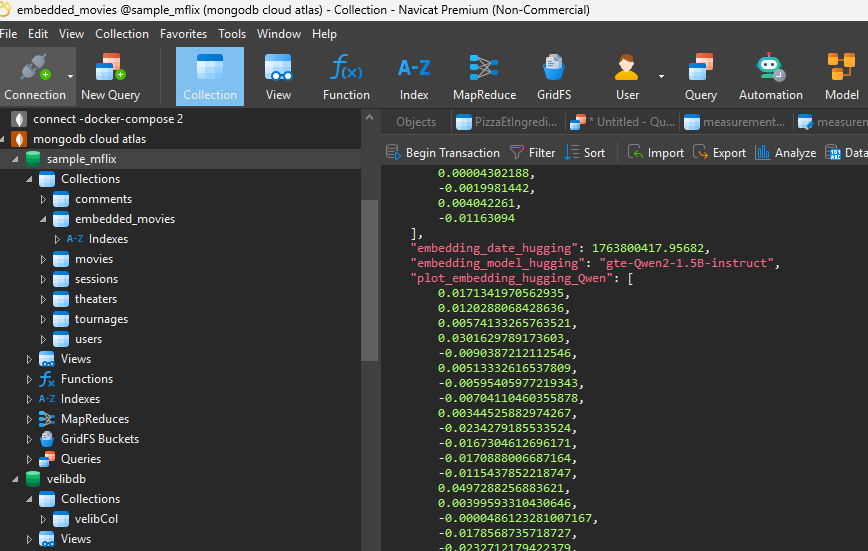

Verification dans navicat connecté au cloud

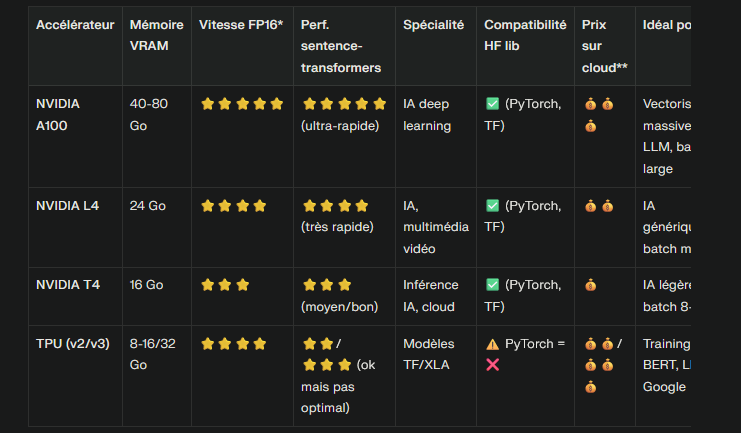

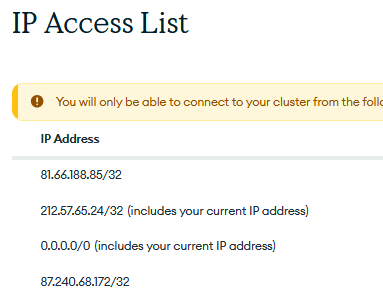

ne pas oublier de modifie la liste des ip dans Atlas

Créer un index vectoriel sur **mongoDB** ( vecteur de 1536 dim)

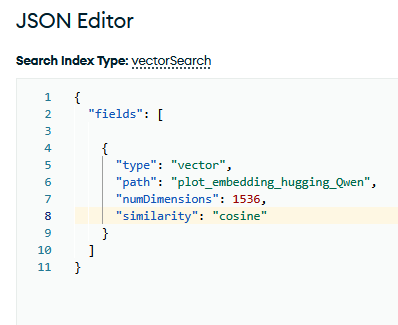

**Attention au champs sur lequel vous placer l'index vectoriel !!!*

Dans MongoDB Atlas (cloud), tu ne peux pas créer d’index vectoriel Search directement avec la méthode classique db.collection.createIndex() ou les commandes mongo shell standards :

    Les index vectorSearch ("Search Indexes") d’Atlas sont gérés par le moteur Atlas Search, pas par le moteur d’indexes classiques MongoDB.

    Ils doivent être créés via l’interface Atlas (UI) ou l’API Atlas (REST, admin SDK).


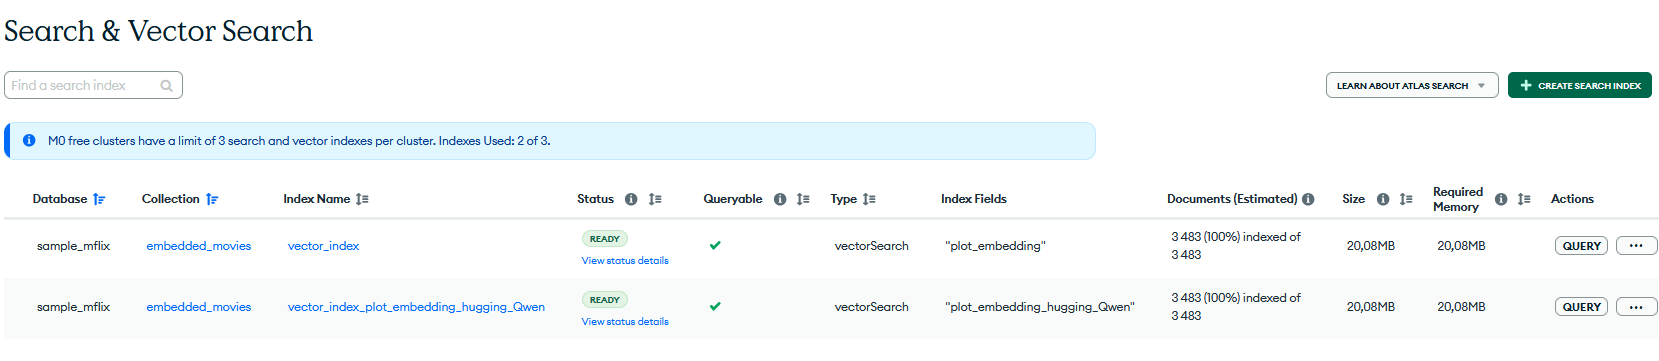



---



---

Requete en similarité en utilisant en Cosine // KNN



---





---



In [ ]:
# from sentence_transformers import SentenceTransformer

# # Charge le modèle sur le même device que pour indexation
# model = SentenceTransformer('Alibaba-NLP/gte-Qwen2-1.5B-instruct')

# Exemple : recherche par titre ou phrase
requete = "A young millionaire falls in love"
# ou requete = "For Heaven's Sake"

query_embedding = model.encode(requete, normalize_embeddings=True).tolist()
query_embedding[:10]

[0.004662696272134781,
 0.03515206277370453,
 0.014927270822227001,
 0.014650491066277027,
 -0.009500871412456036,
 0.01324338000267744,
 -0.022247178480029106,
 0.01301778294146061,
 -0.0008562301518395543,
 -0.008108344860374928]

Construire le pipeline de recherche vectorielle MongoDB

In [ ]:
pipeline = [
    {
        '$vectorSearch': {
            'index': 'vector_index',  #   nom d'index créé dans Atlas
            'path': 'plot_embedding_hugging_Qwen', # Champ des vecteurs 1536 dim
            'queryVector': query_embedding,
            'numCandidates': 150,                 # (optionnel : plus = plus lent mais plus précis)
            'limit': 10                           # Retourner les 10 plus similaires
        }
    },
    {
        '$project': {
            '_id': 0,
            'title': 1,
            'plot': 1,
            'year': 1,
            'genres': 1,
            'score': {'$meta': 'vectorSearchScore'}
        }
    }
]


NumCandidates = le nombre de documents les plus proches (selon l’index vectoriel) récupérés dans la première passe (“pré-filtrage”), avant de trier et limiter aux vrais résultats finaux ('limit': 10 ici).

In [ ]:
results = list(collection.aggregate(pipeline))
results



[{'plot': "Charlie's brother, Sam dies in a car crash that Charlie survives. Charlie is given the gift of seeing his dead brother but when the girl he fell in love with's life is at risk he must choose between his girlfriend and his brother.",
  'genres': ['Drama', 'Fantasy', 'Romance'],
  'title': 'Charlie St. Cloud',
  'year': 2010,
  'score': 0.856539249420166},
 {'year': 2010,
  'plot': 'A bad deed on the part of a tough minor-league hockey player results in an unusual sentence: He must serve one week as a real-life tooth fairy.',
  'genres': ['Comedy', 'Family', 'Fantasy'],
  'title': 'Tooth Fairy',
  'score': 0.8142597675323486},
 {'plot': "Pod is a man without a dream. He's a country bumpkin who comes to work at a tinned sardine factory in Bangkok. One day, Pod chops off his finger and packs it in the can, prompting him to go...",
  'genres': ['Comedy', 'Fantasy', 'Romance'],
  'title': 'Citizen Dog',
  'year': 2004,
  'score': 0.8068255186080933},
 {'year': 2002,
  'plot': 'In 

In [ ]:
print("🎬 Top 10 films similaires :")
for i, film in enumerate(results, 1):
    print(f"\n{i}. {film['title']}")
    print(f"   Année : {film.get('year', 'N/A')}")
    print(f"   Genres : {', '.join(film.get('genres', []))}")
    print(f"   Score : {film['score']:.4f}")
    print(f"   Plot : {film['plot'][:120]}...")

🎬 Top 10 films similaires :

1. Charlie St. Cloud
   Année : 2010
   Genres : Drama, Fantasy, Romance
   Score : 0.8565
   Plot : Charlie's brother, Sam dies in a car crash that Charlie survives. Charlie is given the gift of seeing his dead brother b...

2. Tooth Fairy
   Année : 2010
   Genres : Comedy, Family, Fantasy
   Score : 0.8143
   Plot : A bad deed on the part of a tough minor-league hockey player results in an unusual sentence: He must serve one week as a...

3. Citizen Dog
   Année : 2004
   Genres : Comedy, Fantasy, Romance
   Score : 0.8068
   Plot : Pod is a man without a dream. He's a country bumpkin who comes to work at a tinned sardine factory in Bangkok. One day, ...

4. The Adventures of Pluto Nash
   Année : 2002
   Genres : Comedy, Action, Sci-Fi
   Score : 0.8012
   Plot : In the future, a man struggles to keep his lunar nightclub out of the hands of the mafia....

5. Redirected
   Année : 2014
   Genres : Action, Comedy, Crime
   Score : 0.7970
   Plot : Three f



---



---



---



utilisation d'un outil de traduction avant similarité


Meilleur outil Hugging Face (multilingue) : facebook/m2m100_418M

Alternative rapide/fr-en : Helsinki-NLP/opus-mt-fr-en


In [ ]:
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer

model_name = "facebook/m2m100_418M"
tokenizer = M2M100Tokenizer.from_pretrained(model_name)
model_translation = M2M100ForConditionalGeneration.from_pretrained(model_name)

def translate_fr_en(text: str) -> str:
    tokenizer.src_lang = "fr"
    encoded = tokenizer(text, return_tensors="pt")
    generated_tokens = model_translation.generate(**encoded, forced_bos_token_id=tokenizer.get_lang_id("en"))
    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

def translate_en_fr(text: str) -> str:
    tokenizer.src_lang = "en"
    encoded = tokenizer(text, return_tensors="pt")
    generated_tokens = model_translation.generate(**encoded, forced_bos_token_id=tokenizer.get_lang_id("fr"))
    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
requete_en= translate_fr_en("Un film policier avec un complot surprenant")
print(translate_fr_en("Un film policier avec un complot surprenant"))

tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

A police film with a surprising complot


In [ ]:


query_embedding = model.encode(requete_en, normalize_embeddings=True).tolist()
query_embedding[:10]

[0.02951931767165661,
 -0.02092045359313488,
 -0.0059015280567109585,
 0.025416193529963493,
 0.011568495072424412,
 -0.023298105224967003,
 -0.013090117834508419,
 -0.01354483887553215,
 0.05157799273729324,
 0.006292594596743584]

In [ ]:
pipeline = [
    {
        '$vectorSearch': {
            'index': 'vector_index',  # Ton nom d'index créé dans Atlas
            'path': 'plot_embedding_hugging_Qwen', # Champ des vecteurs 1536 dim
            'queryVector': query_embedding,
            'numCandidates': 150,                 # (optionnel : plus = plus lent mais plus précis)
            'limit': 10                           # Retourner les 10 plus similaires
        }
    },
    {
        '$project': {
            '_id': 0,
            'title': 1,
            'directors':1,
            'writers':1,
            'years':1,
            'release':1,
            'plot': 1,
            'fullplot': 1,
            'year': 1,
            'genres': 1,
            'score': {'$meta': 'vectorSearchScore'}
        }
    }
]

In [ ]:
results = list(collection.aggregate(pipeline))
results

[{'plot': "Pod is a man without a dream. He's a country bumpkin who comes to work at a tinned sardine factory in Bangkok. One day, Pod chops off his finger and packs it in the can, prompting him to go...",
  'genres': ['Comedy', 'Fantasy', 'Romance'],
  'title': 'Citizen Dog',
  'fullplot': "Pod is a man without a dream. He's a country bumpkin who comes to work at a tinned sardine factory in Bangkok. One day, Pod chops off his finger and packs it in the can, prompting him to go around looking for his lost finger at various supermarkets. The incident convinces him to change his job, and Pod becomes a security guard at a large company. There he meets Jin, a lanky maid who carries a mysterious white book around even though she cannot read a single word written in it. The aimless Pod has a crush on Jin, a dreamy girl who dreams that one day she'll be able to decipher the meaning of the white book. In this bright, colour-splashed world of director Wisit Sasanatieng, Bangkokians can grow tai

In [ ]:
print("🎬 Top 10 films similaires :")
for i, film in enumerate(results, 1):
    print(f"\n{i}. {film['title']}")
    print(f"   Année : {film.get('year', 'N/A')}")
    print(f"   Genres : {', '.join(film.get('genres', []))}")
    print(f"   Score : {film['score']:.4f}")
    print(f"   Plot : {translate_en_fr(film['plot'][:120])}...")

🎬 Top 10 films similaires :

1. Citizen Dog
   Année : 2004
   Genres : Comedy, Fantasy, Romance
   Score : 0.7846
   Plot : Pod est un homme sans rêve.Il est un bumpkin du pays qui arrive à travailler dans une usine de sardine à Bangkok.Un jour,...

2. The Adventures of Pluto Nash
   Année : 2002
   Genres : Comedy, Action, Sci-Fi
   Score : 0.7771
   Plot : Dans le futur, un homme se bat pour garder son club nocturne lunaire hors des mains de la mafia....

3. Business Man
   Année : 2012
   Genres : Action, Comedy, Crime
   Score : 0.7713
   Plot : Une jeune fille extrêmement intelligente et ambitieuse "Surya" arrive à Mumbai pour devenir un don de mafia....

4. Rambo
   Année : 2008
   Genres : Action, Thriller, War
   Score : 0.7649
   Plot : En Thaïlande, John Rambo rejoint un groupe de mercenaires pour s'investir dans la tour de guerre de Birmanie, et sauver un groupe d'aide chrétienne...

5. Tooth Fairy
   Année : 2010
   Genres : Comedy, Family, Fantasy
   Score : 0.7569
   Plo



---
Appel a l'agent perplexity pour mettre en forme une belle réponse



---



In [ ]:
!pip install -U langchain-perplexity

In [ ]:
import json
import os
from google.colab import userdata
from langchain_core.messages import SystemMessage, HumanMessage

'''pip install -U langchain-perplexity` '''
from langchain.chat_models import init_chat_model

os.environ["PPLX_API_KEY"] =  userdata.get('secret_PPLX_API_KEY')

# Création du modèle Perplexity Chat
llm = init_chat_model(
    "sonar-pro",  # modèle gratuit
    model_provider="perplexity",
)

envoyer directement cette liste à l’agent pour qu’il produise une belle réponse en français.

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

def pretty_answer_from_results(user_question: str, results: list[dict]) -> str:
    # On prépare un contexte texte à partir du JSON
    lignes = []
    for i, film in enumerate(results, start=1):
        lignes.append(
            f"{i}. {film.get('title')} "
            f"({film.get('year', 'année inconnue')})\n"
            f"   Genres : {', '.join(film.get('genres', []))}\n"
            f"   Résumé : {film.get('plot')}\n"
            f"   Score de similarité : {film.get('score'):.4f}"
        )
    context = "\n\n".join(lignes)

    system_prompt = (
        "Tu es un expert cinéma francophone.\n"
        "On te fournit une question utilisateur et une liste de films "
        "issus d'une base MongoDB (titre, année, genres, résumé, score de similarité).\n"
        "Ta tâche est de répondre en FRANÇAIS, de manière claire et naturelle, "
        "en recommandant ces films à l'utilisateur.\n"
        "Ne mentionne pas MongoDB, les vecteurs ou les scores de similarité dans ta réponse finale."
    )

    user_prompt = (
        f"Question utilisateur : {user_question}\n\n"
        f"Voici les films trouvés (ne montre PAS les scores à l'utilisateur) :\n"
        f"{context}\n\n"
        "Rédige une réponse sympa :\n"
        "- une courte introduction\n"
        "- puis une liste numérotée des films (titre, année, genres, 2–3 phrases de description)\n"
        "- adapte le ton à la question (recommandations de films)."
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = llm.invoke(messages)
    return response.content.strip()

In [ ]:
user_question="j'avais demandé a mongodb de rechercher les 10 films le plus ressamblant a: Un film policier avec un complot surprenant"
answer=pretty_answer_from_results(user_question,results)
print(answer)

Voici une sélection de 10 films qui capturent l'esprit d'un **polar avec un complot surprenant** : des intrigues tordues, des rebondissements inattendus et une bonne dose de suspense. J'ai choisi ceux qui collent le mieux à ta demande, avec un mélange d'action, de crime et de twists malins. À toi de jouer pour une soirée ciné haletante !

1. **Citizen Dog (2004)** – *Comédie, Fantaisie, Romance*  
   Pod, un gars simple d'esprit, arrive à Bangkok pour travailler dans une usine de sardines. Un accident absurde le lance dans une série d'aventures folles où il croise des destins improbables. Attention, les apparences trompent et le complot se révèle de façon hilarante et inattendue.

2. **The Adventures of Pluto Nash (2002)** – *Comédie, Action, Science-fiction*  
   Dans un futur lointain, Pluto Nash gère un nightclub sur la Lune et refuse de le céder à la mafia. Entre fusillades cosmiques et alliances improbables, il découvre un réseau de corruption qui va bien au-delà de ses rêves. Un 

Dans mongodb il n'y a que les textes suivants, on voit que l'agent perplixity a ajouté du contenu

Après que sa boîte de nuit florissante soit réduite en cendres, Pluto et son groupe parcourent la Lune à la recherche d'indices sur l'identité du responsable de l'incendie criminel. Accompagné de Bruno et Dina, Pluto visite un motel miteux, sa cachette secrète et le casino de l'homme le plus puissant de la Lune, toujours à la recherche du coupable. Il finit par découvrir que la destruction de son club est peut-être de sa propre faute,
     

Dans un futur proche, un homme lutte pour empêcher la mafia de s'emparer de sa boîte de nuit lunaire.

On voitqu l'agent a ajouter du texte pour rendre un récit plus attrayant



---



     ** Ajout d'un chatbot rag   **


---



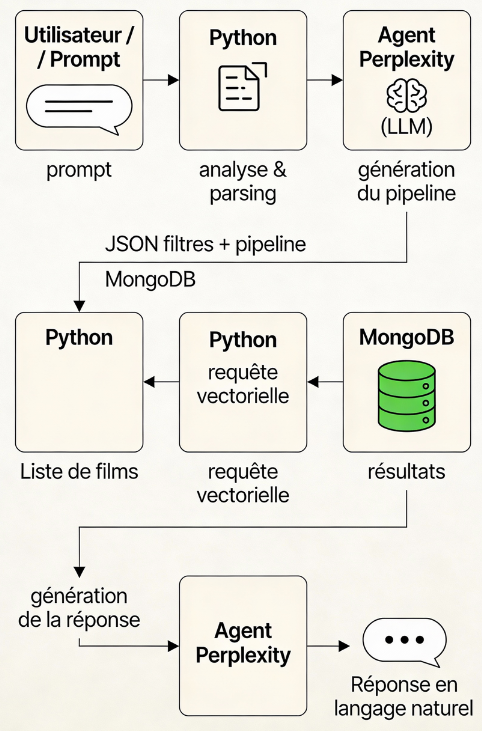

In [ ]:
!pip install -U langchain-perplexity

In [ ]:
import json
import os
from google.colab import userdata
from langchain_core.messages import SystemMessage, HumanMessage

'''pip install -U langchain-perplexity` '''
from langchain.chat_models import init_chat_model

os.environ["PPLX_API_KEY"] =  userdata.get('secret_PPLX_API_KEY')

# Création du modèle Perplexity Chat
llm = init_chat_model(
    "sonar-pro",  # modèle gratuit
    model_provider="perplexity",
)

Fonction : parser la question en JSON

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
import json

def parse_movie_query(user_question: str):
    """
    Envoie la question au LLM Perplexity et récupère un JSON
    avec les infos utiles pour le pipeline MongoDB.
    """
    system_prompt = """
Tu es un assistant francophone qui travaille pour une application de cinéma.

Ta tâche est de transformer une question utilisateur sur des FILMS
en un JSON de filtres pour une base de données.

IMPORTANT :
- L'utilisateur peut poser sa question en FRANÇAIS.
- Tu dois COMPRENDRE le français, mais la clé "semantic_query" doit toujours être en ANGLAIS.
- Tu dois produire UNIQUEMENT un JSON valide, sans aucun texte avant ni après.

Respecte STRICTEMENT ce schéma JSON :

{
  "k": <entier, nombre de films demandés, par défaut 5>,
  "genres": [<liste de genres en anglais, par ex. "Western", "Romance">],
  "semantic_query": <texte court en ANGLAIS résumant ce que doit raconter le film>,
  "order_by": <"rating" ou null>,
  "year_min": <entier ou null>,
  "year_max": <entier ou null>,
  "countries": [<liste de pays en anglais, ex. "USA", "France">],
  "directors": [<liste de noms de réalisateurs (chaînes) ou []>],
  "writers": [<liste de noms de scénaristes ou []>],
  "actors": [<liste de noms d'acteurs/actrices ou []>]
}

Règles de transformation :

- "k" :
  - Si l'utilisateur demande un nombre précis de films (par ex. "3 films", "top 10"), mets cette valeur.
  - Sinon, utilise 5 par défaut.

- "genres" :
  - Déduis les genres à partir de la question.
  - Exemples de mapping :
    - "cowboy", "western" -> "Western"
    - "romantique", "histoire d'amour" -> "Romance"
    - "horreur", "effrayant" -> "Horror"
    - "science-fiction", "SF" -> "Sci-Fi"
    - "comique", "drôle" -> "Comedy"
  - S'il n'y a pas de genre explicite, renvoie [].

- "semantic_query" :
  - Résume en ANGLAIS de quoi doivent parler les films demandés.
  - Exemple : pour "Un film policier avec un complot surprenant", mets
    "a crime movie with a surprising plot twist".

- "order_by" :
  - Mets "rating" uniquement si l'utilisateur demande explicitement un classement
    ("meilleurs", "top", "les plus notés", "best rated", etc.).
  - Sinon, mets null.

- "year_min" / "year_max" :
  - Si l'utilisateur parle d'une période ("années 90", "film récent après 2010", "entre 1980 et 2000"):
    - déduis un intervalle et remplis year_min / year_max.
  - Sinon, mets null pour les deux.

- "countries" :
  - Si l'utilisateur mentionne un pays ou une origine ("film français", "film américain", "film coréen"):
    - renvoie la liste des pays correspondants en anglais (ex: ["France"], ["USA"], ["South Korea"]).
  - Sinon, renvoie [].

- "directors", "writers", "actors" :
  - Si l'utilisateur mentionne des noms précis (réalisateur, scénariste, acteur/actrice),
    ajoute-les dans les listes correspondantes.
  - Sinon, renvoie [].

Ne produis AUCUN autre texte que ce JSON.
Assure-toi que le JSON est syntaxiquement valide (guillemets doubles, pas de commentaires).
"""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Question utilisateur : {user_question}")
    ]

    response = llm.invoke(messages)
    raw = response.content.strip()

    try:
        parsed = json.loads(raw)
    except Exception:
        parsed = {
            "k": 5,
            "genres": [],
            "semantic_query": user_question,
            "order_by": None,
            "year_min": None,
            "year_max": None,
            "countries": [],
            "directors": [],
            "writers": [],
            "actors": [],
        }

    return raw, parsed

Exemple d'utilisation

In [ ]:
user_question = "Je veux 5 films d'action récents avec un acteur connu"

raw_json, filters = parse_movie_query(user_question)
print("JSON renvoyé par le LLM :")
print(raw_json)#string, la réponse brute du LLM
print("\nDict parsé :")
print(filters)#le même JSON mais déjà parsé en dict pas en string, donc directement exploitable en Python

JSON renvoyé par le LLM :
{"k":5,"genres":["Action"],"semantic_query":"recent action movies featuring a well-known actor","order_by":null,"year_min":2020,"year_max":null,"countries":[],"directors":[],"writers":[],"actors":[]}

Dict parsé :
{'k': 5, 'genres': ['Action'], 'semantic_query': 'recent action movies featuring a well-known actor', 'order_by': None, 'year_min': 2020, 'year_max': None, 'countries': [], 'directors': [], 'writers': [], 'actors': []}




---



Fonction : construit le pipeline

In [ ]:

def build_mongodb_pipeline_and_execute(filters: dict, index_name_vector: str = "vector_index"):
    """
    Construit le pipeline MongoDB ($vectorSearch + $project)
    et l'exécute.
    """

    k = filters.get("k", 5)
    genres = filters.get("genres", [])
    semantic_query = filters.get("semantic_query", "")
    year_min = filters.get("year_min")
    year_max = filters.get("year_max")
    countries = filters.get("countries", [])
    directors = filters.get("directors", [])
    writers = filters.get("writers", [])
    actors = filters.get("actors", [])
    order_by = filters.get("order_by")

    query_embedding = model.encode(
        semantic_query,
        normalize_embeddings=True
    ).tolist()

    # filter_clauses = [] #Pour que ces filtres marchent, il faut que ton index vector_index contienne en plus du champ vectoriel les champs filtrés comme filte**

    # if genres:
    #     filter_clauses.append({"genres": {"$in": genres}})

    # if countries:
    #     filter_clauses.append({"countries": {"$in": countries}})

    # if directors:
    #     filter_clauses.append({"directors": {"$in": directors}})

    # if writers:
    #     filter_clauses.append({"writers": {"$in": writers}})

    # if actors:
    #     filter_clauses.append({"cast": {"$in": actors}})

    # if year_min is not None and year_max is not None:
    #     filter_clauses.append({"year": {"$gte": year_min, "$lte": year_max}})
    # elif year_min is not None:
    #     filter_clauses.append({"year": {"$gte": year_min}})
    # elif year_max is not None:
    #     filter_clauses.append({"year": {"$lte": year_max}})

    vector_stage = {
        "$vectorSearch": {
            "index": index_name_vector,
            "queryVector": query_embedding,
            "path": "plot_embedding_hugging_Qwen",
            "numCandidates": 200,
            "limit": k
        }
    }

    # if len(filter_clauses) == 1:
    #     vector_stage["$vectorSearch"]["filter"] = filter_clauses[0]
    # elif len(filter_clauses) > 1:
    #     vector_stage["$vectorSearch"]["filter"] = {"$and": filter_clauses}

    pipeline = [
        vector_stage,
        {
            "$project": {
                "_id": 0,
                "title": 1,
                "year": 1,
                "released": 1,
                "genres": 1,
                "countries": 1,
                "plot": 1,
                "fullplot": 1,
                "directors": {"$slice": ["$directors", 2]},
                "writers": {"$slice": ["$writers", 2]},
                "cast": {"$slice": ["$cast", 3]},
                "score": {"$meta": "vectorSearchScore"}
            }
        }
    ]

    if order_by == "rating":
        pipeline.append({"$sort": {"score": -1}})

    results = list(collection.aggregate(pipeline))
    return pipeline, results

In [ ]:
# #index vectoriel a modifier dans mongodb pour pouvoir filtrer sur ces champs
# '''{
#   "fields": [
#     {
#       "type": "vector",
#       "path": "plot_embedding_hugging_Qwen",
#       "numDimensions": 1536,
#       "similarity": "cosine"
#     },
#     { "type": "filter", "path": "genres" },
#     { "type": "filter", "path": "year" },
#     { "type": "filter", "path": "countries" },
#     { "type": "filter", "path": "directors" },
#     { "type": "filter", "path": "writers" },
#     { "type": "filter", "path": "cast" }
#   ]
# }

Règle pratique

    Sans modification de l’index vectoriel → semantic_query et k sont les seuls vraiment indispensables.

    Avec modification de l’index vectoriel → on peut exploiter genres, year, countries, actors, etc. dans filter

Exemple d'utilisation du pipeline

In [ ]:
user_question = "Je veux 5 films d'action récents avec un acteur connu"

raw_json, filters = parse_movie_query(user_question)
print("JSON renvoyé par le LLM :")
print(raw_json)#string, la réponse brute du LLM
print("\nDict parsé :")
print(filters)#le même JSON mais déjà parsé en dict pas en string, donc directement exploitable en Python

JSON renvoyé par le LLM :
{"k":5,"genres":["Action"],"semantic_query":"recent action movies featuring a well-known actor","order_by":null,"year_min":2020,"year_max":null,"countries":[],"directors":[],"writers":[],"actors":[]}

Dict parsé :
{'k': 5, 'genres': ['Action'], 'semantic_query': 'recent action movies featuring a well-known actor', 'order_by': None, 'year_min': 2020, 'year_max': None, 'countries': [], 'directors': [], 'writers': [], 'actors': []}


In [ ]:

pipeline, results=build_mongodb_pipeline_and_execute(filters)

In [ ]:
pipeline

[{'$vectorSearch': {'index': 'vector_index',
   'queryVector': [0.01077759638428688,
    0.018848305568099022,
    -0.002481382107362151,
    0.0005230644601397216,
    0.0379159115254879,
    0.016961215063929558,
    -0.020156007260084152,
    0.005900026299059391,
    0.008646920323371887,
    0.024872105568647385,
    0.025181720033288002,
    0.09046094119548798,
    -0.005173222161829472,
    0.018352622166275978,
    0.023884134367108345,
    -0.013391160406172276,
    -0.014411966316401958,
    0.008399268612265587,
    -0.007570554502308369,
    -0.02209327183663845,
    -0.023622961714863777,
    -0.025980334728956223,
    0.01952383853495121,
    -0.025216935202479362,
    -0.018672585487365723,
    0.0004384583735372871,
    0.029688064008951187,
    -0.0058401478454470634,
    -0.09665850549936295,
    0.015958737581968307,
    0.0072233472019433975,
    -0.017010264098644257,
    0.03292103111743927,
    0.017308225855231285,
    -0.038932740688323975,
    0.0012420526472

In [ ]:
results

[{'fullplot': "Vietnam veteran John Rambo has survived many harrowing ordeals in his lifetime and has since withdrawn into a simple and secluded existence in Thailand, where he spends his time capturing snakes for local entertainers, and chauffeuring locals in his old PT boat. Even though he is looking to avoid trouble, trouble has a way of finding him: a group of Christian human rights missionaries, led by Michael Burnett and Sarah Miller, approach Rambo with the desire to rent his boat to travel up the river to Burma. For over fifty years, Burma has been a war zone. The Karen people of the region, who consist of peasants and farmers, have endured brutally oppressive rule from the murderous Burmese military and have been struggling for survival every single day. After some inner contemplation, Rambo accepts the offer and takes Michael, Sarah, and the rest of the missionaries up the river. When the missionaries finally arrive at the Karen village, they find themselves part of a raid by



---
On utilise l'agent perplexity pour ameliorer la reponse renvoyée a l'utilsateur , on envoie


---



In [ ]:
# user_question = "Je veux 5 films d'action récents avec un acteur connu"
response_agent=pretty_answer_from_results(user_question,results)

In [ ]:
print(response_agent)

Voici 5 recommandations de **films d'action** récents (années 2007-2014) avec des **acteurs connus**, parfaits pour une dose d'adrénaline ! J'ai sélectionné ces pépites qui collent à tes envies.

1. **Rambo (2008)**  
   Genres : Action, Thriller, Guerre  
   Sylvester Stallone reprend son rôle iconique de John Rambo en Thaïlande, où il aide un groupe de mercenaires à pénétrer en Birmanie en guerre pour sauver des travailleurs humanitaires chrétiens kidnappés par une unité d'infanterie impitoyable. Des scènes explosives et intenses à souhait !

2. **Fantastic 4: Rise of the Silver Surfer (2007)**  
   Genres : Action, Aventure, Fantastique  
   Les Quatre Fantastiques, menés par des stars comme Ioan Gruffudd et Jessica Alba, découvrent qu'ils ne sont pas les seuls super-héros quand ils affrontent le puissant Surfer d'Argent et le dévoreur de planètes Galactus. Un spectacle visuel épique avec des combats cosmiques.

3. **Paragraph 78 (2007)**  
   Genres : Action, Sci-Fi, Thriller  
   

Boucle simple de chat : question -> JSON

In [ ]:
print("=== Chat Movie (Parsing en JSON avec Perplexity) ===")
print("Tape une question (q pour quitter)\n")

while True:
        user_q = input("❓ Outil de recommendation sur les films: ")
        if user_q.lower() in {"q", "quit", "exit"}:
            break

        json_result,filters = parse_movie_query(user_q)
        print("\n📦 JSON interprété par l'agent :")
        print(json_result)
        print("\n🔧 Pipeline MongoDB sera généré a partir de filters:")
        print(filters)
        pipeline,results = build_mongodb_pipeline_and_execute(filters)
        print("\n🎬 Pipeline MongoDB généré :")
        print(json.dumps(pipeline, indent=2))
        print("\n🔧 Filters (dict Python) :")
        print(filters)
        print("envoi a mongodb et affichage de n reponses")


        if not results:
         print("Aucun film trouvé.")

        #*********************************************************
        reponse_finale = pretty_answer_from_results(user_q, results )
        print("\n💬 Réponse finale de l'agent Perplexity :\n")
        print(reponse_finale)
        print("-" * 60)

=== Chat Movie (Parsing en JSON avec Perplexity) ===
Tape une question (q pour quitter)

❓ Outil de recommendation sur les films: Trouve-moi les 5 meilleurs films de cowboy et de science fictio

📦 JSON interprété par l'agent :
{"k":5,"genres":["Western","Sci-Fi"],"semantic_query":"best cowboy and science fiction films","order_by":"rating","year_min":null,"year_max":null,"countries":[],"directors":[],"writers":[],"actors":[]}

🔧 Pipeline MongoDB sera généré a partir de filters:
{'k': 5, 'genres': ['Western', 'Sci-Fi'], 'semantic_query': 'best cowboy and science fiction films', 'order_by': 'rating', 'year_min': None, 'year_max': None, 'countries': [], 'directors': [], 'writers': [], 'actors': []}

🎬 Pipeline MongoDB généré :
[
  {
    "$vectorSearch": {
      "index": "vector_index",
      "queryVector": [
        -0.004760173615068197,
        -0.009787840768694878,
        0.014918209053575993,
        -0.002092507900670171,
        -0.015476529486477375,
        0.004153185989707708,


Exemples:
     # Trouve-moi les 5 meilleurs films de cowboy  et de science fiction.
    # Trouve-moi les 5 meilleurs films de cowboy qui parlent d’une histoire d’amour.

    # Donne-moi 3 films de science-fiction qui explorent les rêves ou les réalités simulées



---



---



Amelioration TP etudiants M2  - ajouter les filters sur :genres, année,directors, writers...



---



---



pour pouvoir utiliser le genre comme "filter" l faut juste modifier l'index vectoriel pour lui dire que 1 ou N champs seront en tant que filtre

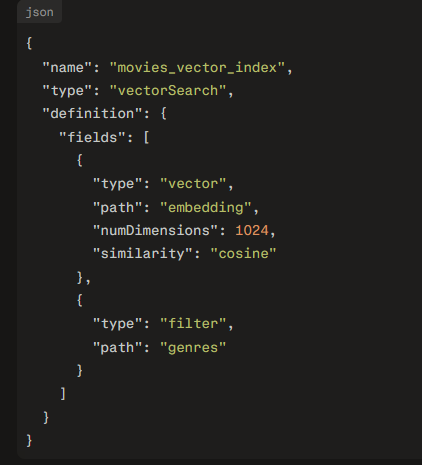

{
  "name": "movies_vector_index",
  "type": "vectorSearch",
  "definition": {
    "fields": [
      {
        "type": "vector",
        "path": "embedding",
        "numDimensions": 1024,
        "similarity": "cosine"
      },
      {
        "type": "filter",
        "path": "genres"
      },
      {
        "type": "filter",
        "path": "year"
      }
    ]
  }
}

Et pour plusieurs champs filtrés

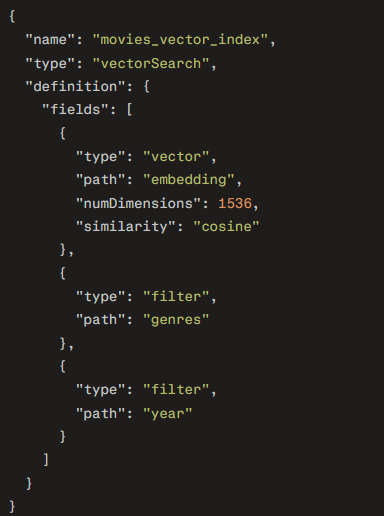

On pourrai rajouter différents filtres...

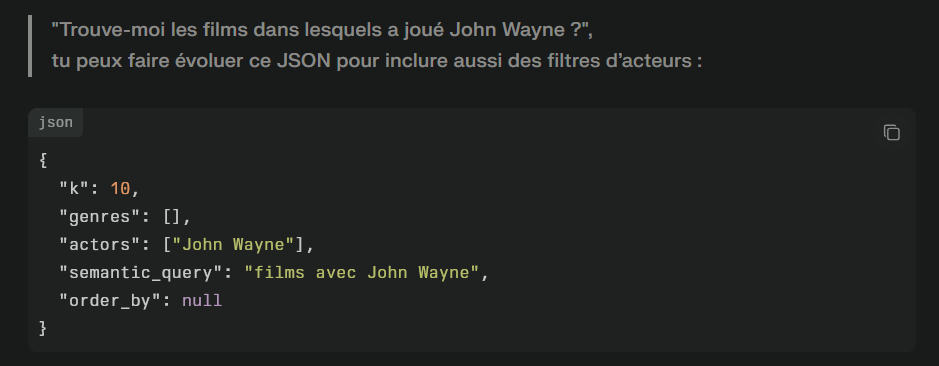

In [ ]:
#Projet a faire pour les étudiants de Master 2 IA...sur l'ajout des filtres'''

A venir...en tp cours mastere IA



---


Reranking
---



---



## Ajout du Re-Ranking avec Cross-Encoder

Le re-ranking permet d'**améliorer la précision** des résultats de la recherche vectorielle.

**Pipeline complet :**
1. **Bi-Encoder** (recherche vectorielle MongoDB) → récupère les top-K candidats (rapide, mais approximatif)
2. **Cross-Encoder** (re-ranker) → réordonne ces candidats avec plus de précision
3. **LLM Perplexity** → formule une belle réponse à partir des meilleurs résultats

Le Cross-Encoder prend en entrée chaque paire `(requête, document)` et attribue un score de pertinence plus fin que la similarité cosinus.

In [ ]:
# Installation du Cross-Encoder (déjà inclus dans sentence-transformers)
# !pip install sentence-transformers  # déjà installé plus haut

In [ ]:
from sentence_transformers import CrossEncoder

# Charger le modèle de re-ranking (Cross-Encoder)
# ms-marco-MiniLM-L-6-v2 : léger, rapide, entraîné sur MS MARCO (question/réponse)
print("📦 Chargement du Cross-Encoder pour le re-ranking...")
# reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")# de plus qur question reponse
reranker = CrossEncoder("cross-encoder/stsb-distilroberta-base")
print("✅ Cross-Encoder chargé!")

📦 Chargement du Cross-Encoder pour le re-ranking...


config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Cross-Encoder chargé!


In [ ]:
def rerank_results(query: str, results: list[dict], top_n: int = 5) -> list[dict]:
    """
    Re-classe les résultats de la recherche vectorielle MongoDB
    en utilisant un Cross-Encoder pour un scoring plus précis.

    Args:
        query: la requête sémantique (en anglais)
        results: liste de dicts MongoDB (avec 'title', 'plot', 'fullplot', 'score'...)
        top_n: nombre de résultats à garder après re-ranking

    Returns:
        Liste triée par score du Cross-Encoder (du plus pertinent au moins pertinent)
    """
    if not results:
        return []

    # Construire les paires (query, document) pour le Cross-Encoder
    pairs = []
    for film in results:
        # On utilise fullplot si disponible, sinon plot, avec le titre
        text = film.get('fullplot') or film.get('plot', '')
        titre = film.get('title', '')
        if titre:
            text = f"{titre}. {text}"
        pairs.append((query, text))

    # Le Cross-Encoder score chaque paire (query, document)
    ce_scores = reranker.predict(pairs)

    # Ajouter le score du Cross-Encoder à chaque résultat
    for film, ce_score in zip(results, ce_scores):
        film['vector_score'] = film.get('score', 0)  # garder l'ancien score vectoriel
        film['rerank_score'] = float(ce_score)         # nouveau score Cross-Encoder

    # Trier par score du Cross-Encoder (décroissant)
    reranked = sorted(results, key=lambda x: x['rerank_score'], reverse=True)

    # Garder seulement les top_n
    return reranked[:top_n]

### Test du Re-Ranking

On récupère **plus de candidats** que nécessaire via `$vectorSearch` (ex: 20),
puis le Cross-Encoder réordonne et ne garde que les **top 5** les plus pertinents.

In [ ]:
# Exemple : on demande 20 candidats à MongoDB, puis le Cross-Encoder garde les 5 meilleurs
user_question_test = "Un film policier avec un complot surprenant"

# Étape 1 : parsing de la question
raw_json, filters = parse_movie_query(user_question_test)
print("📦 Filtres extraits :")
print(json.dumps(filters, indent=2, ensure_ascii=False))

# Étape 2 : on augmente k pour récupérer plus de candidats pour le re-ranking
filters_for_retrieval = filters.copy()
k_final = filters.get('k', 5)               # nombre final voulu par l'utilisateur
filters_for_retrieval['k'] = max(k_final * 4, 20)  # on récupère 4x plus (minimum 20)

print(f"\n🔍 Récupération de {filters_for_retrieval['k']} candidats via recherche vectorielle...")
pipeline, results_bruts = build_mongodb_pipeline_and_execute(filters_for_retrieval)
print(f"   → {len(results_bruts)} résultats récupérés de MongoDB")

# Étape 3 : Re-ranking avec le Cross-Encoder
print(f"\n🔄 Re-ranking des résultats avec le Cross-Encoder...")
results_reranked = rerank_results(
    query=filters['semantic_query'],
    results=results_bruts,
    top_n=k_final
)

# Affichage comparatif
print(f"\n🎬 Top {k_final} films APRÈS re-ranking :")
for i, film in enumerate(results_reranked, 1):
    print(f"\n{i}. {film['title']} ({film.get('year', 'N/A')})")
    print(f"   Genres : {', '.join(film.get('genres', []))}")
    print(f"   Score vectoriel (Bi-Encoder) : {film.get('vector_score', 0):.4f}")
    print(f"   Score re-ranking (Cross-Encoder) : {film['rerank_score']:.4f}")
    print(f"   Plot : {(film.get('plot') or '')[:150]}...")

📦 Filtres extraits :
{
  "k": 5,
  "genres": [
    "Crime"
  ],
  "semantic_query": "a crime movie with a surprising plot twist",
  "order_by": null,
  "year_min": null,
  "year_max": null,
  "countries": [],
  "directors": [],
  "writers": [],
  "actors": []
}

🔍 Récupération de 20 candidats via recherche vectorielle...
   → 20 résultats récupérés de MongoDB

🔄 Re-ranking des résultats avec le Cross-Encoder...

🎬 Top 5 films APRÈS re-ranking :

1. A Better Tomorrow III: Love and Death in Saigon (1989)
   Genres : Action, War
   Score vectoriel (Bi-Encoder) : 0.7704
   Score re-ranking (Cross-Encoder) : 0.4574
   Plot : A man travels from China to Vietnam, on the brink of war with America, to retrieve his uncle and cousin but find complications when he falls in love w...

2. After Life (1998)
   Genres : Drama, Fantasy
   Score vectoriel (Bi-Encoder) : 0.7549
   Score re-ranking (Cross-Encoder) : 0.4499
   Plot : After death, people have just one week to choose only a memory to keep fo

In [ ]:
# Étape 4 : Envoi des résultats re-rankés à l'agent Perplexity
reponse_finale = pretty_answer_from_results(user_question_test, results_reranked)
print("\n💬 Réponse finale (après re-ranking) :\n")
print(reponse_finale)


💬 Réponse finale (après re-ranking) :

Voici quelques recommandations de **films policiers** (ou très proches) avec des **complots surprenants** qui devraient vous plaire. Ils regorgent de twists inattendus et de rebondissements haletants !

1. **Rambo (2008)**  
   Genres : Action, Thriller, Guerre  
   John Rambo, en Thaïlande, accepte de guider un groupe de mercenaires pour secourir des travailleurs humanitaires chrétiens kidnappés en Birmanie par une unité d'infanterie impitoyable. Ce qui commence comme une mission de sauvetage se transforme en un engrenage de trahisons et de complots militaires explosives. Un pur concentré d'adrénaline avec des révélations choc.

2. **A Better Tomorrow III: Love and Death in Saigon (1989)**  
   Genres : Action, Guerre  
   Un homme venant de Chine se rend au Vietnam, au bord de la guerre avec l'Amérique, pour retrouver son oncle et sa cousine. Mais il tombe amoureux d'une gangster aux côtés dangereux, ce qui l'implique dans un réseau de trahison

In [ ]:
def pretty_answer_from_results_with_fallback(user_question: str, weak_results: list[dict]) -> str:
    lignes = []
    for i, film in enumerate(weak_results, start=1):
        lignes.append(
            f"{i}. {film.get('title')} "
            f"({film.get('year', 'année inconnue')})\n"
            f"   Genres : {', '.join(film.get('genres', []))}\n"
            f"   Résumé : {film.get('plot')}\n"
            f"   Score de pertinence : {film.get('rerank_score'):.4f}"
        )
    context = "\n\n".join(lignes)

    system_prompt = (
        "Tu es un expert cinéma francophone.\n"
        "On te fournit une question utilisateur et une liste de films "
        "issus d'une base MongoDB, MAIS ces films ont un score de pertinence très faible.\n"
        "Cela signifie que la base de données ne contient probablement pas de films "
        "correspondant vraiment à la demande.\n\n"
        "Ta tâche :\n"
        "1. Indique clairement que ces films viennent de la base mais ne correspondent pas bien.\n"
        "2. Propose ensuite des films plus pertinents issus de TES propres connaissances.\n"
        "3. Sépare bien les deux sections avec des titres clairs.\n"
        "4. Réponds en FRANÇAIS.\n"
        "Ne mentionne pas MongoDB, les vecteurs ou les scores."
    )

    user_prompt = (
        f"Question utilisateur : {user_question}\n\n"
        f"Films trouvés dans la base (FAIBLE pertinence) :\n"
        f"{context}\n\n"
        "Rédige une réponse avec :\n"
        "- D'abord : signale que la base ne contient pas de films très pertinents\n"
        "- Ensuite : recommande des films de tes connaissances qui correspondent mieux\n"
        "- Adapte le ton (recommandations cinéma, sympa et naturel)."
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = llm.invoke(messages)
    return response.content.strip()

### Boucle de chat complète avec Re-Ranking

Le pipeline complet : **Question → Parsing LLM → Recherche vectorielle (top-K large) → Re-Ranking Cross-Encoder → Réponse LLM**

In [ ]:
print("=== Chat Movie avec Re-Ranking ===")
print("Tape une question (q pour quitter)\n")

while True:
    user_q = input("❓ Outil de recommendation sur les films: ")
    if user_q.lower() in {"q", "quit", "exit"}:
        break

    # 1. Parsing de la question en JSON
    json_result, filters = parse_movie_query(user_q)
    print("\n📦 JSON interprété par l'agent :")
    print(json_result)

    # 2. Recherche vectorielle avec plus de candidats
    k_final = filters.get('k', 5)
    filters_retrieval = filters.copy()
    filters_retrieval['k'] = max(k_final * 4, 20)  # récupérer 4x plus pour le re-ranking

    pipeline, results_bruts = build_mongodb_pipeline_and_execute(filters_retrieval)
    print(f"\n🔍 {len(results_bruts)} candidats récupérés via recherche vectorielle")

    if not results_bruts:
        print("Aucun film trouvé.")
        continue

    # 3. Re-ranking avec Cross-Encoder
    results_reranked = rerank_results(
        query=filters['semantic_query'],
        results=results_bruts,
        top_n=k_final
    )


    # Séparer les résultats pertinents des non-pertinents
    SEUIL_RERANK = -5.0  # seuil ajustable selon tes tests

    results_pertinents = [f for f in results_reranked if f['rerank_score'] > SEUIL_RERANK]
    results_faibles = [f for f in results_reranked if f['rerank_score'] <= SEUIL_RERANK]

    print(f"🔄 Re-ranking terminé → top {k_final} sélectionnés")

    # Affichage des scores comparatifs
    print("\n📊 Comparaison des scores :")
    for i, film in enumerate(results_reranked, 1):
        print(f"  {i}. {film['title']} | vectoriel: {film.get('vector_score', 0):.4f} | rerank: {film['rerank_score']:.4f}")

    # 4. Réponse finale par l'agent Perplexity


    if results_pertinents:
      # Cas normal : on a des bons résultats de MongoDB
      reponse_finale = pretty_answer_from_results(user_q, results_pertinents)
    else:
      # Aucun résultat pertinent dans MongoDB → on le dit à Perplexity
      print(f"⚠️ Aucun résultat pertinent dans MongoDB (meilleur score: {results_reranked[0]['rerank_score']:.2f})")
      reponse_finale = pretty_answer_from_results_with_fallback(user_q, results_faibles)
    print("\n💬 Réponse finale de l'agent Perplexity :\n")
    print(reponse_finale)
    print("-" * 60)

=== Chat Movie avec Re-Ranking ===
Tape une question (q pour quitter)

❓ Outil de recommendation sur les films: donne 5 flms de cowboys et de science fiction

📦 JSON interprété par l'agent :
{"k":5,"genres":["Western","Sci-Fi"],"semantic_query":"movies blending cowboys and science fiction themes","order_by":null,"year_min":null,"year_max":null,"countries":[],"directors":[],"writers":[],"actors":[]}

🔍 20 candidats récupérés via recherche vectorielle
🔄 Re-ranking terminé → top 5 sélectionnés

📊 Comparaison des scores :
  1. After Life | vectoriel: 0.7138 | rerank: 0.4503
  2. A Better Tomorrow III: Love and Death in Saigon | vectoriel: 0.7549 | rerank: 0.4433
  3. Rambo | vectoriel: 0.7959 | rerank: 0.4332
  4. Mr Perfect | vectoriel: 0.7481 | rerank: 0.4247
  5. Rio Grande | vectoriel: 0.7803 | rerank: 0.3797

💬 Réponse finale de l'agent Perplexity :

Voici 5 recommandations de films qui mêlent habilement l'univers des cowboys au genre science-fiction (ou très proches, comme les wester

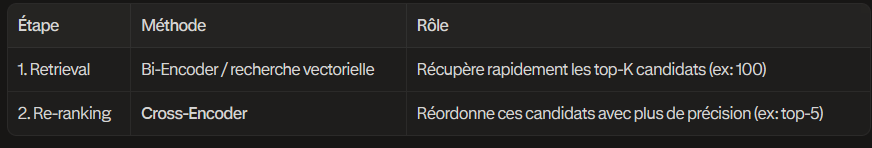



---


Amelioration
---



---



In [ ]:
# def build_text_for_embedding_amelioreration(movie):
#     parts = []

#     if movie.get("title"):
#         parts.append(f"Title: {movie['title']}")

#     if movie.get("genres"):
#         parts.append(f"Genres: {', '.join(movie['genres'])}")

#     if movie.get("directors"):
#         parts.append(f"Directors: {', '.join(movie['directors'])}")

#     if movie.get("cast"):
#         parts.append(f"Cast: {', '.join(movie['cast'][:5])}")  # top 5

#     if movie.get("awards", {}).get("text"):
#         parts.append(f"Awards: {movie['awards']['text']}")

#     if movie.get("plot"):           # si présent quand même
#         parts.append(f"Plot: {movie['plot']}")

#     if movie.get("fullplot"):       # idem
#         parts.append(f"Full plot: {movie['fullplot']}")

#     return " | ".join(parts)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
import json

def parse_movie_query_amelioration(user_question: str):
    """
    Envoie la question au LLM Perplexity et récupère un JSON
    avec les infos utiles pour le pipeline MongoDB.
    """
    system_prompt = """
Tu es un assistant francophone qui travaille pour une application de cinéma.

Ta tâche est de transformer une question utilisateur sur des FILMS
en un JSON de filtres pour une base de données.

IMPORTANT :
- L'utilisateur peut poser sa question en FRANÇAIS.
- Tu dois COMPRENDRE le français, mais la clé "semantic_query" doit toujours être en ANGLAIS.
- Tu dois produire UNIQUEMENT un JSON valide, sans aucun texte avant ni après.

Respecte STRICTEMENT ce schéma JSON :

{
  "k": <entier, nombre de films demandés, par défaut 5>,
  "genres": [<liste de genres en anglais, par ex. "Western", "Romance">],
  "semantic_query": <texte court en ANGLAIS résumant ce que doit raconter le film>,
  "order_by": <"rating" ou null>,
  "year_min": <entier ou null>,
  "year_max": <entier ou null>,
  "countries": [<liste de pays en anglais, ex. "USA", "France">],
  "directors": [<liste de noms de réalisateurs (chaînes) ou []>],
  "writers": [<liste de noms de scénaristes ou []>],
  "actors": [<liste de noms d'acteurs/actrices ou []>]
  "title": <titre du film>

}

Règles de transformation :

- "k" :
  - Si l'utilisateur demande un nombre précis de films (par ex. "3 films", "top 10"), mets cette valeur.
  - Sinon, utilise 5 par défaut.

- "genres" :
  - Déduis les genres à partir de la question.
  - Exemples de mapping :
    - "cowboy", "western" -> "Western"
    - "romantique", "histoire d'amour" -> "Romance"
    - "horreur", "effrayant" -> "Horror"
    - "science-fiction", "SF" -> "Sci-Fi"
    - "comique", "drôle" -> "Comedy"
  - S'il n'y a pas de genre explicite, renvoie [].

- "semantic_query" :
  - Résume en ANGLAIS de quoi doivent parler les films demandés.
  - Exemple : pour "Un film policier avec un complot surprenant", mets
    "a crime movie with a surprising plot twist".

- "order_by" :
  - Mets "rating" uniquement si l'utilisateur demande explicitement un classement
    ("meilleurs", "top", "les plus notés", "best rated", etc.).
  - Sinon, mets null.

- "year_min" / "year_max" :
  - Si l'utilisateur parle d'une période ("années 90", "film récent après 2010", "entre 1980 et 2000"):
    - déduis un intervalle et remplis year_min / year_max.
  - Sinon, mets null pour les deux.

- "countries" :
  - Si l'utilisateur mentionne un pays ou une origine ("film français", "film américain", "film coréen"):
    - renvoie la liste des pays correspondants en anglais (ex: ["France"], ["USA"], ["South Korea"]).
    -si tu trouves un indice indique le pays que tu imagines
  - Sinon, renvoie [].

- "directors", "writers", "actors" :
  - Si l'utilisateur mentionne des noms précis (réalisateur, scénariste, acteur/actrice),
    ajoute-les dans les listes correspondantes.
    -si tu trouves un indice indique le directeur que tu imagines
  - Sinon, renvoie [].

- "title" :
  - Si l'utilisateur mentionne un titre de film précis, mets-le ici.
  - Exemple : "des films comme Inception" → "title": "Inception"
  - Si aucun titre n'est mentionné, mets null.
  - Ne JAMAIS inventer un titre.


Ne produis AUCUN autre texte que ce JSON.
Assure-toi que le JSON est syntaxiquement valide (guillemets doubles, pas de commentaires).
"""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Question utilisateur : {user_question}")
    ]

    response = llm.invoke(messages)
    raw = response.content.strip()

    try:
        parsed = json.loads(raw)
    except Exception:
        parsed = {
            "k": 5,
            "genres": [],
            "semantic_query": user_question,
            "order_by": None,
            "year_min": None,
            "year_max": None,
            "countries": [],
            "directors": [],
            "writers": [],
            "actors": [],
        }

    return raw, parsed

In [ ]:
def build_mongodb_pipeline_and_execute_amelioration(filters: dict, index_name_vector: str = "vector_index"):
    """
    Construit le pipeline MongoDB ($vectorSearch + $project)
    et l'exécute.
    """

    k = filters.get("k", 5)
    genres = filters.get("genres", [])
    semantic_query = filters.get("semantic_query", "")
    year_min = filters.get("year_min")
    year_max = filters.get("year_max")
    countries = filters.get("countries", [])
    directors = filters.get("directors", [])
    writers = filters.get("writers", [])
    actors = filters.get("actors", [])
    order_by = filters.get("order_by")
    title= filters.get("title")
    # Construire le pipeline

    parts = []

    parts.append(f"Title: { title }")

    parts.append(f"Genres: {', '.join(genres)}")

    parts.append(f"Directors: {', '.join(directors)}")

    parts.append(f"Cast: {', '.join(actors)}")

    parts.append(f"Awards: []")

    parts.append(f"Plot:  {semantic_query  }")

    parts.append(f"Full plot: { semantic_query }")

    semantic_query_amelioration= " | ".join(parts)


    query_embedding = model.encode(
        semantic_query_amelioration,
        normalize_embeddings=True
    ).tolist()

    # filter_clauses = [] #Pour que ces filtres marchent, il faut que ton index vector_index contienne en plus du champ vectoriel les champs filtrés comme filte**

    # if genres:
    #     filter_clauses.append({"genres": {"$in": genres}})

    # if countries:
    #     filter_clauses.append({"countries": {"$in": countries}})

    # if directors:
    #     filter_clauses.append({"directors": {"$in": directors}})

    # if writers:
    #     filter_clauses.append({"writers": {"$in": writers}})

    # if actors:
    #     filter_clauses.append({"cast": {"$in": actors}})

    # if year_min is not None and year_max is not None:
    #     filter_clauses.append({"year": {"$gte": year_min, "$lte": year_max}})
    # elif year_min is not None:
    #     filter_clauses.append({"year": {"$gte": year_min}})
    # elif year_max is not None:
    #     filter_clauses.append({"year": {"$lte": year_max}})

    vector_stage = {
        "$vectorSearch": {
            "index": index_name_vector,
            "queryVector": query_embedding,
            "path": "plot_embedding_hugging_Qwen",
            "numCandidates": 200,
            "limit": k
        }
    }

    # if len(filter_clauses) == 1:
    #     vector_stage["$vectorSearch"]["filter"] = filter_clauses[0]
    # elif len(filter_clauses) > 1:
    #     vector_stage["$vectorSearch"]["filter"] = {"$and": filter_clauses}

    pipeline = [
        vector_stage,
        {
            "$project": {
                "_id": 0,
                "title": 1,
                "year": 1,
                "released": 1,
                "genres": 1,
                "countries": 1,
                "plot": 1,
                "fullplot": 1,
                "directors": {"$slice": ["$directors", 2]},
                "writers": {"$slice": ["$writers", 2]},
                "cast": {"$slice": ["$cast", 3]},
                "score": {"$meta": "vectorSearchScore"}
            }
        }
    ]

    if order_by == "rating":
        pipeline.append({"$sort": {"score": -1}})

    results = list(collection.aggregate(pipeline))
    return pipeline, results

In [ ]:
print("=== Chat Movie avec Re-Ranking ===")
print("Tape une question (q pour quitter)\n")

while True:
    user_q = input("❓ Outil de recommendation sur les films: ")
    if user_q.lower() in {"q", "quit", "exit"}:
        break

    # 1. Parsing de la question en JSON
    json_result, filters = parse_movie_query_amelioration(user_q)
    print("\n📦 JSON interprété par l'agent :")
    print(json_result)

    # 2. Recherche vectorielle avec plus de candidats
    k_final = filters.get('k', 5)
    filters_retrieval = filters.copy()
    filters_retrieval['k'] = max(k_final * 4, 20)  # récupérer 4x plus pour le re-ranking

    pipeline, results_bruts = build_mongodb_pipeline_and_execute_amelioration(filters_retrieval)
    print(f"\n🔍 {len(results_bruts)} candidats récupérés via recherche vectorielle")

    if not results_bruts:
        print("Aucun film trouvé.")
        continue

    # 3. Re-ranking avec Cross-Encoder
    results_reranked = rerank_results(
        query=filters['semantic_query'],
        results=results_bruts,
        top_n=k_final
    )


    # Séparer les résultats pertinents des non-pertinents
    SEUIL_RERANK = -5.0  # seuil ajustable selon tes tests

    results_pertinents = [f for f in results_reranked if f['rerank_score'] > SEUIL_RERANK]
    results_faibles = [f for f in results_reranked if f['rerank_score'] <= SEUIL_RERANK]

    print(f"🔄 Re-ranking terminé → top {k_final} sélectionnés")

    # Affichage des scores comparatifs
    print("\n📊 Comparaison des scores :")
    for i, film in enumerate(results_reranked, 1):
        print(f"  {i}. {film['title']} | vectoriel: {film.get('vector_score', 0):.4f} | rerank: {film['rerank_score']:.4f}")

    # 4. Réponse finale par l'agent Perplexity


    if results_pertinents:
      # Cas normal : on a des bons résultats de MongoDB
      reponse_finale = pretty_answer_from_results(user_q, results_pertinents)
    else:
      # Aucun résultat pertinent dans MongoDB → on le dit à Perplexity
      print(f"⚠️ Aucun résultat pertinent dans MongoDB (meilleur score: {results_reranked[0]['rerank_score']:.2f})")
      reponse_finale = pretty_answer_from_results_with_fallback(user_q, results_faibles)
    print("\n💬 Réponse finale de l'agent Perplexity :\n")
    print(reponse_finale)
    print("-" * 60)

=== Chat Movie avec Re-Ranking ===
Tape une question (q pour quitter)

❓ Outil de recommendation sur les films: donne 5 films de qi parle de cowboys et scienfiction

📦 JSON interprété par l'agent :
{"k":5,"genres":["Western","Sci-Fi"],"semantic_query":"movies about cowboys and science fiction","order_by":null,"year_min":null,"year_max":null,"countries":[],"directors":[],"writers":[],"actors":[],"title":null}

🔍 20 candidats récupérés via recherche vectorielle
🔄 Re-ranking terminé → top 5 sélectionnés

📊 Comparaison des scores :
  1. Cowboys & Aliens | vectoriel: 0.7446 | rerank: 0.3318
  2. Another World | vectoriel: 0.7432 | rerank: 0.3116
  3. Battlefield Earth | vectoriel: 0.7285 | rerank: 0.3083
  4. Citizen Dog | vectoriel: 0.7336 | rerank: 0.2861
  5. Westworld | vectoriel: 0.7287 | rerank: 0.2582

💬 Réponse finale de l'agent Perplexity :

Voici 5 films géniaux qui mêlent **cowboys** et **science-fiction** dans un style western spatial ultra-sympa ! Parfait pour des aventures épi